In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
print(train.shape, test.shape)

(891, 12) (418, 11)


In [3]:
def prepare(df, age_median, embarked_mode):
    df = df.copy()
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Age'] = df['Age'].fillna(age_median)
    df['Embarked'] = df['Embarked'].fillna(embarked_mode)
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())  # 1 NaN dans test
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
    df = df.drop(columns=['Name', 'Ticket', 'Cabin'])
    return df

age_median = train['Age'].median()
embarked_mode = train['Embarked'].mode()[0]

train_prep = prepare(train, age_median, embarked_mode)
test_prep = prepare(test, age_median, embarked_mode)

train_prep.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,False,True
1,2,1,1,1,38.0,1,0,71.2833,False,False
2,3,1,3,1,26.0,0,0,7.9250,False,True
3,4,1,1,1,35.0,1,0,53.1000,False,True
4,5,0,3,0,35.0,0,0,8.0500,False,True


In [4]:
X = train_prep.drop(columns=['Survived', 'PassengerId'])
y = train_prep['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_val.shape)

(712, 8) (179, 8)


In [5]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

val_preds = model.predict(X_val)
print(f"Accuracy validation: {accuracy_score(y_val, val_preds):.4f}")
print(classification_report(y_val, val_preds))

Accuracy validation: 0.8101
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



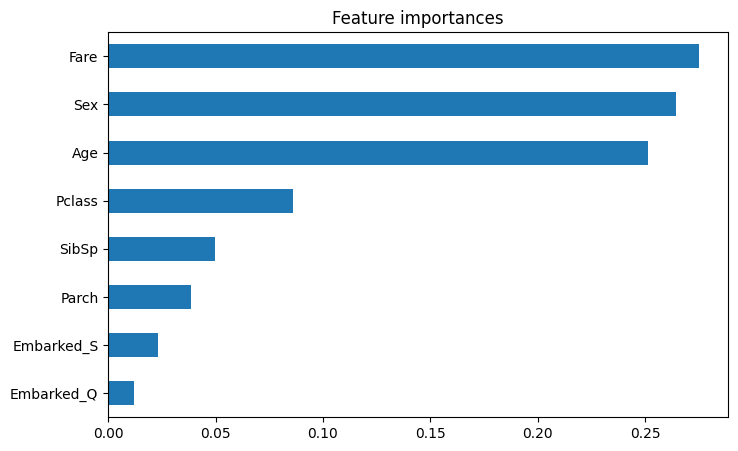

In [6]:
import matplotlib.pyplot as plt
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importances.plot.barh(figsize=(8, 5))
plt.title("Feature importances")
plt.show()

In [7]:
X_test = test_prep.drop(columns=['PassengerId'])
test_preds = model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_preds
})
submission.to_csv('../submission.csv', index=False)
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0
